# SKU-level Sales Cost Forecasting — v2 (+ Promotions)
**Data**: `../historical_sales_data.csv` · `../promotional_data.csv` — 1 store, ~29 K SKUs  
**Target**: `当天全部销售成本金额` (daily total cost of sales)  
**Horizon**: 28 days · **CV**: 3-fold walk-forward  
**Primary metric**: MAE · **Secondary**: sMAPE (non-zero days)  
**New in v2**: 8 promotion features — `is_promo`, `discount_depth`, type flags (bundle / threshold / warehouse / online), `days_since_promo`, `rolling_promo_7`

In [1]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from prophet import Prophet

HORIZON   = 28
N_FOLDS   = 3
MIN_HIST  = HORIZON * (N_FOLDS + 1)   # 112 days
SAMPLE    = 50    # SKUs per segment for per-SKU model CV
SEED      = 42
TARGET    = '当天全部销售成本金额'
DATE_COL  = '日期(年月日)'
SKU_COL   = '条形码'

Importing plotly failed. Interactive plots will not work.


## 1. Load & Profile

In [2]:
df = pd.read_csv('../historical_sales_data.csv', parse_dates=[DATE_COL],
                 usecols=[SKU_COL, DATE_COL, TARGET])

print('Unique stores in data:', pd.read_csv('../historical_sales_data.csv', usecols=['门店编码'])['门店编码'].nunique())
print(f'Shape: {df.shape}')
print(f'Date range: {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}')
print(f'Unique SKUs: {df[SKU_COL].nunique():,}')
print(f'Zero-cost rows: {(df[TARGET]==0).mean():.1%}')

Unique stores in data: 1
Shape: (3202501, 3)
Date range: 2023-08-01 → 2025-07-31
Unique SKUs: 29,488
Zero-cost rows: 1.4%


In [3]:
promo_raw = pd.read_csv('../promotional_data.csv', parse_dates=['日期'])
promo_raw = promo_raw.rename(columns={
    '日期': DATE_COL, '条形码': SKU_COL,
    '促销类型': 'promo_type', '折扣率': 'discount_rate'
})

# Promotion type groupings
BUNDLE_TYPES    = frozenset({'组合促销', '线上组合促销'})
THRESHOLD_TYPES = frozenset({'满额促销', '线上满额促销折扣'})
WAREHOUSE_TYPES = frozenset({'库区折率单折扣'})
ONLINE_TYPES    = frozenset({'超市线上促销', '线上组合促销', '线上满额促销折扣'})

PROMO_STATIC_COLS = ['is_promo', 'discount_depth', 'is_bundle_promo',
                     'is_threshold_promo', 'is_warehouse_discount', 'is_online_promo']
PROMO_COLS = PROMO_STATIC_COLS + ['days_since_promo', 'rolling_promo_7']

# Aggregate to (SKU, date): take minimum discount rate, flag all promo types present
_agg = promo_raw.groupby([SKU_COL, DATE_COL]).agg(
    min_discount_rate=('discount_rate', 'min'),
    promo_types=('promo_type', lambda x: frozenset(x))
).reset_index()

_agg['is_promo']             = 1.0
_agg['discount_depth']       = (1.0 - _agg['min_discount_rate']).clip(lower=0)
_agg['is_bundle_promo']      = _agg['promo_types'].apply(lambda s: float(bool(s & BUNDLE_TYPES)))
_agg['is_threshold_promo']   = _agg['promo_types'].apply(lambda s: float(bool(s & THRESHOLD_TYPES)))
_agg['is_warehouse_discount']= _agg['promo_types'].apply(lambda s: float(bool(s & WAREHOUSE_TYPES)))
_agg['is_online_promo']      = _agg['promo_types'].apply(lambda s: float(bool(s & ONLINE_TYPES)))

promo_feat = _agg[[SKU_COL, DATE_COL] + PROMO_STATIC_COLS].copy()

print(f'Promo feature table: {promo_feat.shape}')
print(f'Date range : {promo_feat[DATE_COL].min().date()} → {promo_feat[DATE_COL].max().date()}')
print(f'Unique SKUs: {promo_feat[SKU_COL].nunique():,}')
print(f'\nPromo type coverage (SKU-day records):')
for col in PROMO_STATIC_COLS[2:]:
    print(f'  {col:<25}: {int(promo_feat[col].sum()):>8,}')
print(f'\nMean discount depth on promo days: '
      f'{promo_feat.loc[promo_feat["is_promo"]==1,"discount_depth"].mean():.3f}')

Promo feature table: (3656308, 8)
Date range : 2023-08-01 → 2025-09-25
Unique SKUs: 20,621

Promo type coverage (SKU-day records):
  is_bundle_promo          :  448,938
  is_threshold_promo       :  346,475
  is_warehouse_discount    : 2,853,767
  is_online_promo          :   83,955

Mean discount depth on promo days: 0.057


## 1b. Load & Build Promotion Features

## 2. Train / Test Split + SKU Segmentation

In [4]:
GLOBAL_END   = df[DATE_COL].max()
TEST_START   = GLOBAL_END - pd.Timedelta(days=HORIZON - 1)   # last 28 days
TRAIN_END    = TEST_START - pd.Timedelta(days=1)

print(f'Training: up to {TRAIN_END.date()}')
print(f'Test    : {TEST_START.date()} → {GLOBAL_END.date()} ({HORIZON} days)')

train_df = df[df[DATE_COL] <= TRAIN_END].copy()
test_df  = df[df[DATE_COL] >= TEST_START].copy()

# Count training days per SKU (missing days = 0 sales, still count as history)
sku_train_days = train_df.groupby(SKU_COL)[DATE_COL].apply(
    lambda s: (s.max() - s.min()).days + 1
).rename('span_days')

eligible = sku_train_days[sku_train_days >= MIN_HIST].index
print(f'\nEligible SKUs (>= {MIN_HIST} day span in training): {len(eligible):,} '
      f'({100*len(eligible)/df[SKU_COL].nunique():.1f}%)')

# Segment
short_skus = sku_train_days[(sku_train_days >= MIN_HIST) & (sku_train_days < 180)].index
long_skus  = sku_train_days[sku_train_days >= 180].index
print(f'Short-history segment ({MIN_HIST}–179 days): {len(short_skus):,}')
print(f'Long-history  segment (≥ 180 days)        : {len(long_skus):,}')

Training: up to 2025-07-03
Test    : 2025-07-04 → 2025-07-31 (28 days)

Eligible SKUs (>= 112 day span in training): 20,412 (69.2%)
Short-history segment (112–179 days): 2,445
Long-history  segment (≥ 180 days)        : 17,967


## 3. Helper Functions

In [5]:
def smape(y_true, y_pred):
    """Symmetric MAPE — range [0, 200]. Secondary metric, non-zero days only."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask  = denom > 0
    return 100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])


def mae(y_true, y_pred):
    """Mean Absolute Error — primary selection metric."""
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))


def fill_daily(series: pd.Series) -> pd.Series:
    """Reindex to a full daily date range, filling gaps with 0."""
    full_idx = pd.date_range(series.index.min(), series.index.max(), freq='D')
    return series.reindex(full_idx, fill_value=0.0)


def sku_series(sku, src=None):
    """Return a complete daily series for one SKU from src (default train_df)."""
    src = train_df if src is None else src
    s = src[src[SKU_COL] == sku].set_index(DATE_COL)[TARGET].sort_index()
    return fill_daily(s)


def walk_forward_cv(sku, forecast_fn, n_folds=N_FOLDS, horizon=HORIZON):
    """
    Walk-forward CV for a single SKU.
    Returns (mean MAE, mean sMAPE-nonzero) across folds, or (NaN, NaN) on failure.
    """
    series = sku_series(sku)
    n      = len(series)
    maes, smapes_nz = [], []
    for fold in range(n_folds, 0, -1):
        test_end   = n - (fold - 1) * horizon
        test_start = test_end - horizon
        if test_start < horizon:
            continue
        train_part = series.iloc[:test_start]
        test_part  = series.iloc[test_start:test_end].values
        try:
            preds = forecast_fn(train_part, horizon)
            maes.append(mae(test_part, preds))
            # sMAPE only on non-zero actual days
            nz = test_part > 0
            if nz.sum() > 0:
                smapes_nz.append(smape(test_part[nz], preds[nz]))
        except Exception:
            pass
    mean_mae    = np.mean(maes)       if maes       else np.nan
    mean_smape  = np.mean(smapes_nz)  if smapes_nz  else np.nan
    return mean_mae, mean_smape

## 4. Model Implementations

In [6]:
# ── Seasonal Naïve (7-day period) ──────────────────────────────────────────
def naive_forecast(train: pd.Series, horizon: int, period: int = 7) -> np.ndarray:
    last_cycle = train.values[-period:]
    repeats    = int(np.ceil(horizon / period))
    return np.tile(last_cycle, repeats)[:horizon]


# ── Holt-Winters — with progressive fallback ───────────────────────────────
def hw_forecast(train: pd.Series, horizon: int, period: int = 7) -> np.ndarray:
    values  = train.values.astype(float)
    nonzero = (values != 0).sum()
    if len(values) < 2 * period or nonzero < period:
        return naive_forecast(train, horizon, period)
    eps = 1e-3
    v   = values + eps
    configs = [
        dict(trend='add', seasonal='add',  seasonal_periods=period, initialization_method='heuristic'),
        dict(trend=None,  seasonal='add',  seasonal_periods=period, initialization_method='heuristic'),
        dict(trend=None,  seasonal='add',  seasonal_periods=period, initialization_method='legacy-heuristic'),
        dict(trend=None,  seasonal=None),
    ]
    for cfg in configs:
        try:
            fit   = ExponentialSmoothing(v, **cfg).fit(optimized=True, disp=False)
            preds = fit.forecast(horizon) - eps
            if not np.any(np.isnan(preds)):
                return np.maximum(preds, 0.0)
        except Exception:
            pass
    return naive_forecast(train, horizon, period)


# ── Prophet ────────────────────────────────────────────────────────────────
def prophet_forecast(train: pd.Series, horizon: int) -> np.ndarray:
    if (train > 0).sum() < 2:
        return naive_forecast(train, horizon)
    df_p = pd.DataFrame({'ds': train.index, 'y': train.values.astype(float)})
    try:
        m = Prophet(weekly_seasonality=True, yearly_seasonality=False,
                    daily_seasonality=False, seasonality_mode='additive')
        m.fit(df_p)
        future   = m.make_future_dataframe(periods=horizon, freq='D')
        forecast = m.predict(future)
        return np.maximum(forecast['yhat'].tail(horizon).values, 0.0)
    except Exception:
        return naive_forecast(train, horizon)


# ── Smoke-test ─────────────────────────────────────────────────────────────
import traceback
_test_sku = short_skus[0] if len(short_skus) > 0 else long_skus[0]
_s = sku_series(_test_sku)
print(f'Test SKU: {len(_s)} days, {int((_s>0).sum())} non-zero')
for _name, _fn in [('hw_forecast', hw_forecast), ('prophet_forecast', prophet_forecast)]:
    try:
        _p = _fn(_s, HORIZON)
        print(f'  {_name} OK — first 3 preds: {np.round(_p[:3], 3)}')
    except Exception as _e:
        traceback.print_exc()
print('Model functions defined.')

00:13:31 - cmdstanpy - INFO - Chain [1] start processing
00:13:31 - cmdstanpy - INFO - Chain [1] done processing


Test SKU: 170 days, 28 non-zero
  hw_forecast OK — first 3 preds: [40.32 23.64 27.  ]
  prophet_forecast OK — first 3 preds: [35.779 36.602 35.24 ]
Model functions defined.


## 5. Walk-Forward CV — Per-SKU Models (Naïve · Holt-Winters · Prophet)

In [7]:
rng = np.random.default_rng(SEED)

sample_short = rng.choice(short_skus, size=min(SAMPLE, len(short_skus)), replace=False)
sample_long  = rng.choice(long_skus,  size=min(SAMPLE, len(long_skus)),  replace=False)

# Prophet is ~2–3s per fit; 50 SKUs × 3 folds × 2 segments ≈ 5–10 min
PER_SKU_MODELS = [
    ('naive',        naive_forecast),
    ('holt_winters', hw_forecast),
    ('prophet',      prophet_forecast),
]

results = {}
for seg_name, sample in [('short', sample_short), ('long', sample_long)]:
    results[seg_name] = {m: {'mae': [], 'smape_nz': []} for m, _ in PER_SKU_MODELS}
    for sku in sample:
        for model_name, fn in PER_SKU_MODELS:
            m, s = walk_forward_cv(sku, fn)
            results[seg_name][model_name]['mae'].append(m)
            results[seg_name][model_name]['smape_nz'].append(s)

    print(f'\n── {seg_name} segment ──')
    for model_name, _ in PER_SKU_MODELS:
        vals    = results[seg_name][model_name]
        mae_arr = np.array(vals['mae'])
        smp_arr = np.array(vals['smape_nz'])
        print(f'  {model_name:14s} | mean MAE = {np.nanmean(mae_arr):8.3f} '
              f'| median MAE = {np.nanmedian(mae_arr):8.3f} '
              f'| sMAPE(nz) = {np.nanmean(smp_arr):6.2f} '
              f'| valid = {(~np.isnan(mae_arr)).sum()}/{len(mae_arr)}')

00:13:31 - cmdstanpy - INFO - Chain [1] start processing
00:13:32 - cmdstanpy - INFO - Chain [1] done processing
00:13:32 - cmdstanpy - INFO - Chain [1] start processing
00:13:32 - cmdstanpy - INFO - Chain [1] done processing
00:13:32 - cmdstanpy - INFO - Chain [1] start processing
00:13:32 - cmdstanpy - INFO - Chain [1] done processing
00:13:32 - cmdstanpy - INFO - Chain [1] start processing
00:13:32 - cmdstanpy - INFO - Chain [1] done processing
00:13:32 - cmdstanpy - INFO - Chain [1] start processing
00:13:32 - cmdstanpy - INFO - Chain [1] done processing
00:13:32 - cmdstanpy - INFO - Chain [1] start processing
00:13:32 - cmdstanpy - INFO - Chain [1] done processing
00:13:33 - cmdstanpy - INFO - Chain [1] start processing
00:13:33 - cmdstanpy - INFO - Chain [1] done processing
00:13:33 - cmdstanpy - INFO - Chain [1] start processing
00:13:33 - cmdstanpy - INFO - Chain [1] done processing
00:13:33 - cmdstanpy - INFO - Chain [1] start processing
00:13:33 - cmdstanpy - INFO - Chain [1]


── short segment ──
  naive          | mean MAE =    8.193 | median MAE =    4.160 | sMAPE(nz) = 172.04 | valid = 50/50
  holt_winters   | mean MAE =    8.193 | median MAE =    4.160 | sMAPE(nz) = 172.04 | valid = 50/50
  prophet        | mean MAE =    7.389 | median MAE =    4.072 | sMAPE(nz) = 159.15 | valid = 50/50


00:13:50 - cmdstanpy - INFO - Chain [1] start processing
00:13:50 - cmdstanpy - INFO - Chain [1] done processing
00:13:50 - cmdstanpy - INFO - Chain [1] start processing
00:13:50 - cmdstanpy - INFO - Chain [1] done processing
00:13:51 - cmdstanpy - INFO - Chain [1] start processing
00:13:51 - cmdstanpy - INFO - Chain [1] done processing
00:13:51 - cmdstanpy - INFO - Chain [1] start processing
00:13:51 - cmdstanpy - INFO - Chain [1] done processing
00:13:51 - cmdstanpy - INFO - Chain [1] start processing
00:13:51 - cmdstanpy - INFO - Chain [1] done processing
00:13:51 - cmdstanpy - INFO - Chain [1] start processing
00:13:51 - cmdstanpy - INFO - Chain [1] done processing
00:13:51 - cmdstanpy - INFO - Chain [1] start processing
00:13:51 - cmdstanpy - INFO - Chain [1] done processing
00:13:51 - cmdstanpy - INFO - Chain [1] start processing
00:13:51 - cmdstanpy - INFO - Chain [1] done processing
00:13:51 - cmdstanpy - INFO - Chain [1] start processing
00:13:51 - cmdstanpy - INFO - Chain [1]


── long segment ──
  naive          | mean MAE =   29.624 | median MAE =    7.462 | sMAPE(nz) = 146.20 | valid = 50/50
  holt_winters   | mean MAE =   29.624 | median MAE =    7.462 | sMAPE(nz) = 146.20 | valid = 50/50
  prophet        | mean MAE =   30.828 | median MAE =    7.936 | sMAPE(nz) = 120.06 | valid = 50/50


## 6. Global Models (HistGBM · Ridge · Random Forest · LightGBM)

In [8]:
def make_features(df_src: pd.DataFrame) -> pd.DataFrame:
    records = []
    for sku, grp in df_src[df_src[SKU_COL].isin(eligible)].groupby(SKU_COL):
        s = grp.set_index(DATE_COL)[TARGET].sort_index()
        s = fill_daily(s)
        feat = pd.DataFrame({'date': s.index, 'y': s.values, 'sku': sku})
        for lag in [1, 2, 3, 7, 14, 21, 28]:
            feat[f'lag_{lag}'] = s.shift(lag).values
        feat['roll7']  = s.shift(1).rolling(7,  min_periods=1).mean().values
        feat['roll14'] = s.shift(1).rolling(14, min_periods=1).mean().values
        feat['roll28'] = s.shift(1).rolling(28, min_periods=1).mean().values
        feat['dow']    = feat['date'].dt.dayofweek
        feat['dom']    = feat['date'].dt.day
        feat['month']  = feat['date'].dt.month
        records.append(feat)
    result = pd.concat(records, ignore_index=True)

    # ── Merge static promotion features ─────────────────────────────────────
    result = result.merge(
        promo_feat.rename(columns={SKU_COL: 'sku', DATE_COL: 'date'}),
        on=['sku', 'date'], how='left'
    )
    result[PROMO_STATIC_COLS] = result[PROMO_STATIC_COLS].fillna(0.0)

    # ── days_since_promo: running days since last is_promo == 1 ──────────────
    def _days_since(arr):
        out  = np.empty(len(arr))
        days = 999
        for i, v in enumerate(arr):
            if v == 1.0:
                days = 0
            out[i] = float(days)
            days    = min(days + 1, 999)
        return out

    result['days_since_promo'] = (
        result.groupby('sku')['is_promo']
        .transform(lambda s: _days_since(s.values))
    )

    # ── rolling_promo_7: promo days in past 7 days (shift(1) avoids leakage) ─
    result['rolling_promo_7'] = (
        result.groupby('sku')['is_promo']
        .transform(lambda s: s.shift(1).rolling(7, min_periods=1).sum().fillna(0))
    )

    return result


print('Building feature matrix for eligible SKUs — may take a minute...')
feat_df = make_features(train_df)
print(f'Feature matrix: {feat_df.shape}')
print(f'Promo coverage: {feat_df["is_promo"].mean():.1%} of rows have is_promo=1')
feat_df.head(3)

Building feature matrix for eligible SKUs — may take a minute...
Feature matrix: (8864172, 24)
Promo coverage: 8.7% of rows have is_promo=1


,date,y,sku,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_28,...,dom,month,is_promo,discount_depth,is_bundle_promo,is_threshold_promo,is_warehouse_discount,is_online_promo,days_since_promo,rolling_promo_7
0,2024-03-10,6.571,+++OHUvaW8zxBQY07bEnAQ==,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10,3,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0.0
1,2024-03-11,0.000,+++OHUvaW8zxBQY07bEnAQ==,6.571,NaN,NaN,NaN,NaN,NaN,NaN,...,11,3,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0.0
2,2024-03-12,0.000,+++OHUvaW8zxBQY07bEnAQ==,0.000,6.571,NaN,NaN,NaN,NaN,NaN,...,12,3,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0.0


In [9]:
sku_enc = {s: i for i, s in enumerate(feat_df['sku'].unique())}
feat_df['sku_id'] = feat_df['sku'].map(sku_enc)

FEATURE_COLS = (
    ['sku_id', 'lag_1','lag_2','lag_3','lag_7','lag_14','lag_21','lag_28',
     'roll7','roll14','roll28','dow','dom','month']
    + PROMO_COLS   # 8 promotion features appended
)
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

all_dates = feat_df['date'].sort_values().unique()

fold_splits = []
for fold in range(N_FOLDS, 0, -1):
    cutoff     = all_dates[-(fold * HORIZON) - 1]
    fold_start = all_dates[-(fold * HORIZON)]
    fold_end   = all_dates[-(fold * HORIZON) + HORIZON - 1]
    tr = feat_df[feat_df['date'] <= cutoff].dropna(subset=FEATURE_COLS)
    te = feat_df[(feat_df['date'] >= fold_start) & (feat_df['date'] <= fold_end)].dropna(subset=FEATURE_COLS)
    fold_splits.append((cutoff, fold_start, fold_end, tr, te))

global_cv_results = {}

def run_global_cv(name, model):
    seg_results = {'short': {'maes': [], 'smapes_nz': []},
                   'long':  {'maes': [], 'smapes_nz': []}}
    for cutoff, fold_start, fold_end, tr, te in fold_splits:
        model.fit(tr[FEATURE_COLS], tr['y'])
        preds = model.predict(te[FEATURE_COLS])
        te_with_pred = te.assign(pred=preds)
        for seg_name, seg_skus in [('short', short_skus), ('long', long_skus)]:
            te_seg = te_with_pred[te_with_pred['sku'].isin(seg_skus)]
            if len(te_seg) == 0:
                continue
            fold_mae   = mae(te_seg['y'].values, te_seg['pred'].values)
            nz         = te_seg['y'].values > 0
            fold_smape = smape(te_seg['y'].values[nz], te_seg['pred'].values[nz]) if nz.sum() > 0 else np.nan
            seg_results[seg_name]['maes'].append(fold_mae)
            seg_results[seg_name]['smapes_nz'].append(fold_smape)
        print(f'  [{name}] fold train≤{pd.Timestamp(cutoff).date()} '
              f'| short MAE={seg_results["short"]["maes"][-1]:.4f} '
              f'| long MAE={seg_results["long"]["maes"][-1]:.4f}')
    global_cv_results[name] = seg_results
    for seg_name, res in seg_results.items():
        print(f'  → [{name}] {seg_name:5s}  mean MAE={np.mean(res["maes"]):.4f}  '
              f'mean sMAPE(nz)={np.nanmean(res["smapes_nz"]):.2f}')
    print()

print('── HistGradientBoosting ──')
run_global_cv('hist_gbm', HistGradientBoostingRegressor(
    max_iter=200, learning_rate=0.05, max_depth=6,
    min_samples_leaf=20, random_state=SEED
))

cv_maes      = global_cv_results['hist_gbm']['long']['maes']
cv_smapes_nz = global_cv_results['hist_gbm']['long']['smapes_nz']

Feature columns (22): ['sku_id', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'roll7', 'roll14', 'roll28', 'dow', 'dom', 'month', 'is_promo', 'discount_depth', 'is_bundle_promo', 'is_threshold_promo', 'is_warehouse_discount', 'is_online_promo', 'days_since_promo', 'rolling_promo_7']
── HistGradientBoosting ──
  [hist_gbm] fold train≤2025-04-10 | short MAE=17.9358 | long MAE=22.1183
  [hist_gbm] fold train≤2025-05-08 | short MAE=17.3299 | long MAE=25.0850
  [hist_gbm] fold train≤2025-06-05 | short MAE=16.3200 | long MAE=24.6886
  → [hist_gbm] short  mean MAE=17.1953  mean sMAPE(nz)=64.97
  → [hist_gbm] long   mean MAE=23.9639  mean sMAPE(nz)=60.66



In [10]:
print('── Ridge Regression ──')
run_global_cv('ridge', Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
]))

print('── Random Forest ──')
run_global_cv('random_forest', RandomForestRegressor(
    n_estimators=100, max_depth=10,
    max_samples=0.3, max_features=0.7,
    n_jobs=-1, random_state=SEED
))

print('── LightGBM ──')
run_global_cv('lightgbm', lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=31, min_child_samples=20,
    n_jobs=-1, random_state=SEED, verbose=-1
))

── Ridge Regression ──
  [ridge] fold train≤2025-04-10 | short MAE=20.5840 | long MAE=24.9718
  [ridge] fold train≤2025-05-08 | short MAE=20.9035 | long MAE=28.0322
  [ridge] fold train≤2025-06-05 | short MAE=19.3118 | long MAE=27.4141
  → [ridge] short  mean MAE=20.2665  mean sMAPE(nz)=63.79
  → [ridge] long   mean MAE=26.8060  mean sMAPE(nz)=60.06

── Random Forest ──
  [random_forest] fold train≤2025-04-10 | short MAE=16.7856 | long MAE=21.3776
  [random_forest] fold train≤2025-05-08 | short MAE=17.1004 | long MAE=25.0965
  [random_forest] fold train≤2025-06-05 | short MAE=16.0582 | long MAE=24.2939
  → [random_forest] short  mean MAE=16.6481  mean sMAPE(nz)=69.68
  → [random_forest] long   mean MAE=23.5893  mean sMAPE(nz)=63.67

── LightGBM ──
  [lightgbm] fold train≤2025-04-10 | short MAE=16.3679 | long MAE=21.2663
  [lightgbm] fold train≤2025-05-08 | short MAE=16.2993 | long MAE=25.2872
  [lightgbm] fold train≤2025-06-05 | short MAE=15.6606 | long MAE=23.8653
  → [lightgbm] short

In [11]:
summary_rows = []

# Per-SKU models (sampled)
for seg, models in results.items():
    for model, vals in models.items():
        summary_rows.append({
            'Segment': seg, 'Model': model, 'Scope': 'per-SKU',
            'Mean MAE':   round(np.nanmean(vals['mae']), 4),
            'Median MAE': round(np.nanmedian(vals['mae']), 4),
            'sMAPE(nz)':  round(np.nanmean(vals['smape_nz']), 2),
        })

# Global models — one row per segment for apples-to-apples comparison
for model_name, seg_results in global_cv_results.items():
    for seg_name, res in seg_results.items():
        summary_rows.append({
            'Segment': seg_name, 'Model': model_name, 'Scope': 'global',
            'Mean MAE':   round(np.mean(res['maes']), 4),
            'Median MAE': round(np.mean(res['maes']), 4),
            'sMAPE(nz)':  round(np.nanmean(res['smapes_nz']), 2),
        })

summary = pd.DataFrame(summary_rows).sort_values(['Segment', 'Mean MAE'])
print(summary.to_string(index=False))

# Best global model per segment
global_summary = summary[summary['Scope'] == 'global']
best_per_seg = global_summary.loc[global_summary.groupby('Segment')['Mean MAE'].idxmin()]
print('\nBest global model per segment:')
print(best_per_seg[['Segment', 'Model', 'Mean MAE', 'sMAPE(nz)']].to_string(index=False))

# Overall best global model (by mean MAE across segments) for final retraining
best_global_name = (global_summary.groupby('Model')['Mean MAE']
                    .mean().idxmin())
best_global = global_summary[global_summary['Model'] == best_global_name].iloc[0]
print(f'\nOverall best global model for retraining: {best_global_name}')

Segment         Model   Scope  Mean MAE  Median MAE  sMAPE(nz)
   long      lightgbm  global   23.4730     23.4730      66.08
   long random_forest  global   23.5893     23.5893      63.67
   long      hist_gbm  global   23.9639     23.9639      60.66
   long         ridge  global   26.8060     26.8060      60.06
   long         naive per-SKU   29.6238      7.4618     146.20
   long  holt_winters per-SKU   29.6238      7.4618     146.20
   long       prophet per-SKU   30.8280      7.9363     120.06
  short       prophet per-SKU    7.3894      4.0716     159.15
  short         naive per-SKU    8.1931      4.1601     172.04
  short  holt_winters per-SKU    8.1931      4.1601     172.04
  short      lightgbm  global   16.1093     16.1093      72.64
  short random_forest  global   16.6481     16.6481      69.68
  short      hist_gbm  global   17.1953     17.1953      64.97
  short         ridge  global   20.2665     20.2665      63.79

Best global model per segment:
Segment    Model  Mean 

## 8. Final Test-Set Evaluation

In [12]:
print('Building full feature matrix (train + test for lag lookups)...')
feat_df_test = make_features(df)
feat_df_test['sku_id'] = feat_df_test['sku'].map(sku_enc)

tr_full = feat_df_test[feat_df_test['date'] <= TRAIN_END].dropna(subset=FEATURE_COLS)
te_base = feat_df_test[feat_df_test['date'] >= TEST_START].dropna(subset=FEATURE_COLS).copy()

final_models = {
    'hist_gbm': HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=6,
        min_samples_leaf=20, random_state=SEED),
    'ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'random_forest': RandomForestRegressor(
        n_estimators=100, max_depth=10,
        max_samples=0.3, max_features=0.7,
        n_jobs=-1, random_state=SEED),
    'lightgbm': lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        num_leaves=31, min_child_samples=20,
        n_jobs=-1, random_state=SEED, verbose=-1),
}

test_global_results = {}
for name, model in final_models.items():
    print(f'  Training {name}...')
    model.fit(tr_full[FEATURE_COLS], tr_full['y'])
    preds = model.predict(te_base[FEATURE_COLS])
    nz    = te_base['y'].values > 0
    test_global_results[name] = {
        'model': model, 'preds': preds,
        'mae':      mae(te_base['y'].values, preds),
        'smape_nz': smape(te_base['y'].values[nz], preds[nz]) if nz.sum() > 0 else np.nan,
    }

te_final     = te_base.copy()
te_final['pred'] = test_global_results[best_global_name]['preds']
final_model      = test_global_results[best_global_name]['model']
print(f'\nBest model for final evaluation: {best_global_name}')

Building full feature matrix (train + test for lag lookups)...
  Training hist_gbm...
  Training ridge...
  Training random_forest...
  Training lightgbm...

Best model for final evaluation: lightgbm


In [13]:
sample_test = rng.choice(eligible, size=min(100, len(eligible)), replace=False)
all_test    = df[df[DATE_COL] >= TEST_START]
test_idx    = pd.date_range(TEST_START, GLOBAL_END, freq='D')

naive_maes, hw_maes, prophet_maes = [], [], []
naive_smapes_nz, hw_smapes_nz, prophet_smapes_nz = [], [], []

for sku in sample_test:
    train_s = sku_series(sku, train_df)
    y_true  = (all_test[all_test[SKU_COL] == sku]
               .set_index(DATE_COL)[TARGET].sort_index()
               .reindex(test_idx, fill_value=0.0).values)
    if y_true.sum() == 0:
        continue
    nz = y_true > 0
    for preds, mae_list, smape_list in [
        (naive_forecast(train_s, HORIZON),   naive_maes,   naive_smapes_nz),
        (hw_forecast(train_s, HORIZON),      hw_maes,      hw_smapes_nz),
        (prophet_forecast(train_s, HORIZON), prophet_maes, prophet_smapes_nz),
    ]:
        mae_list.append(mae(y_true, preds))
        if nz.sum() > 0:
            smape_list.append(smape(y_true[nz], preds[nz]))

naive_mae_mean = np.nanmean(naive_maes)

print(f'{"Model":<28} {"MAE":>10}  {"sMAPE(nz)":>10}  {"vs Naïve":>10}')
print('-' * 64)
print(f'{"Seasonal Naïve (sample)":<28} {naive_mae_mean:>10.4f}  {np.nanmean(naive_smapes_nz):>10.2f}  {"baseline":>10}')
print(f'{"Holt-Winters (sample)":<28} {np.nanmean(hw_maes):>10.4f}  {np.nanmean(hw_smapes_nz):>10.2f}  {(np.nanmean(hw_maes)/naive_mae_mean-1)*100:>+9.1f}%')
print(f'{"Prophet (sample)":<28} {np.nanmean(prophet_maes):>10.4f}  {np.nanmean(prophet_smapes_nz):>10.2f}  {(np.nanmean(prophet_maes)/naive_mae_mean-1)*100:>+9.1f}%')
for name, res in test_global_results.items():
    marker = ' ← best CV' if name == best_global_name else ''
    print(f'{name:<28} {res["mae"]:>10.4f}  {res["smape_nz"]:>10.2f}  {(res["mae"]/naive_mae_mean-1)*100:>+9.1f}%{marker}')

00:32:05 - cmdstanpy - INFO - Chain [1] start processing
00:32:05 - cmdstanpy - INFO - Chain [1] done processing
00:32:05 - cmdstanpy - INFO - Chain [1] start processing
00:32:05 - cmdstanpy - INFO - Chain [1] done processing
00:32:05 - cmdstanpy - INFO - Chain [1] start processing
00:32:05 - cmdstanpy - INFO - Chain [1] done processing
00:32:06 - cmdstanpy - INFO - Chain [1] start processing
00:32:06 - cmdstanpy - INFO - Chain [1] done processing
00:32:06 - cmdstanpy - INFO - Chain [1] start processing
00:32:06 - cmdstanpy - INFO - Chain [1] done processing
00:32:06 - cmdstanpy - INFO - Chain [1] start processing
00:32:06 - cmdstanpy - INFO - Chain [1] done processing
00:32:06 - cmdstanpy - INFO - Chain [1] start processing
00:32:06 - cmdstanpy - INFO - Chain [1] done processing
00:32:07 - cmdstanpy - INFO - Chain [1] start processing
00:32:07 - cmdstanpy - INFO - Chain [1] done processing
00:32:07 - cmdstanpy - INFO - Chain [1] start processing
00:32:07 - cmdstanpy - INFO - Chain [1]

Model                               MAE   sMAPE(nz)    vs Naïve
----------------------------------------------------------------
Seasonal Naïve (sample)         28.5217      124.68    baseline
Holt-Winters (sample)           28.5217      124.68       +0.0%
Prophet (sample)                25.1861      102.07      -11.7%
hist_gbm                        22.4013       59.39      -21.5%
ridge                           24.5331       59.07      -14.0%
random_forest                   22.1602       62.63      -22.3%
lightgbm                        22.2819       64.89      -21.9% ← best CV


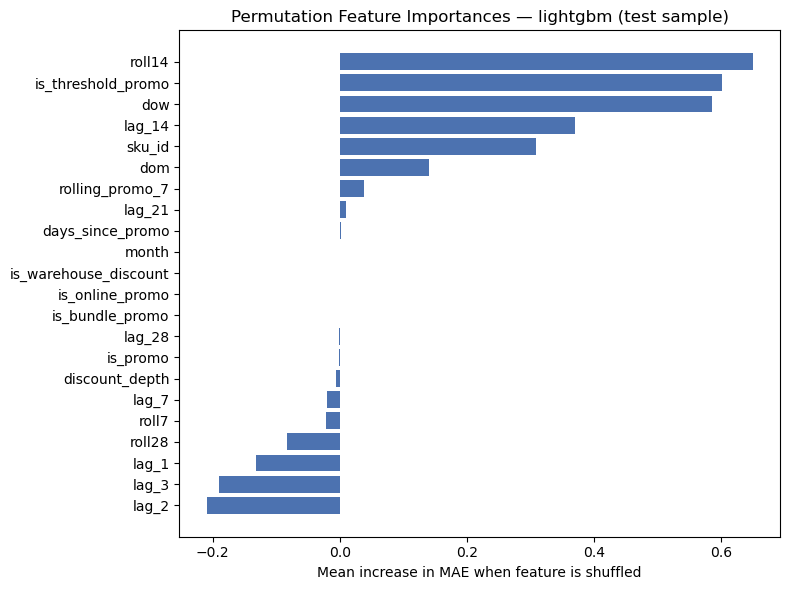

In [14]:
from sklearn.inspection import permutation_importance

sample_idx = rng.choice(len(te_final), size=min(5000, len(te_final)), replace=False)
te_sample  = te_final.iloc[sample_idx]

perm = permutation_importance(
    final_model,
    te_sample[FEATURE_COLS], te_sample['y'],
    n_repeats=5, random_state=SEED, n_jobs=-1
)

importances = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances.index, importances.values, color='#4C72B0')
ax.set_title(f'Permutation Feature Importances — {best_global_name} (test sample)')
ax.set_xlabel('Mean increase in MAE when feature is shuffled')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

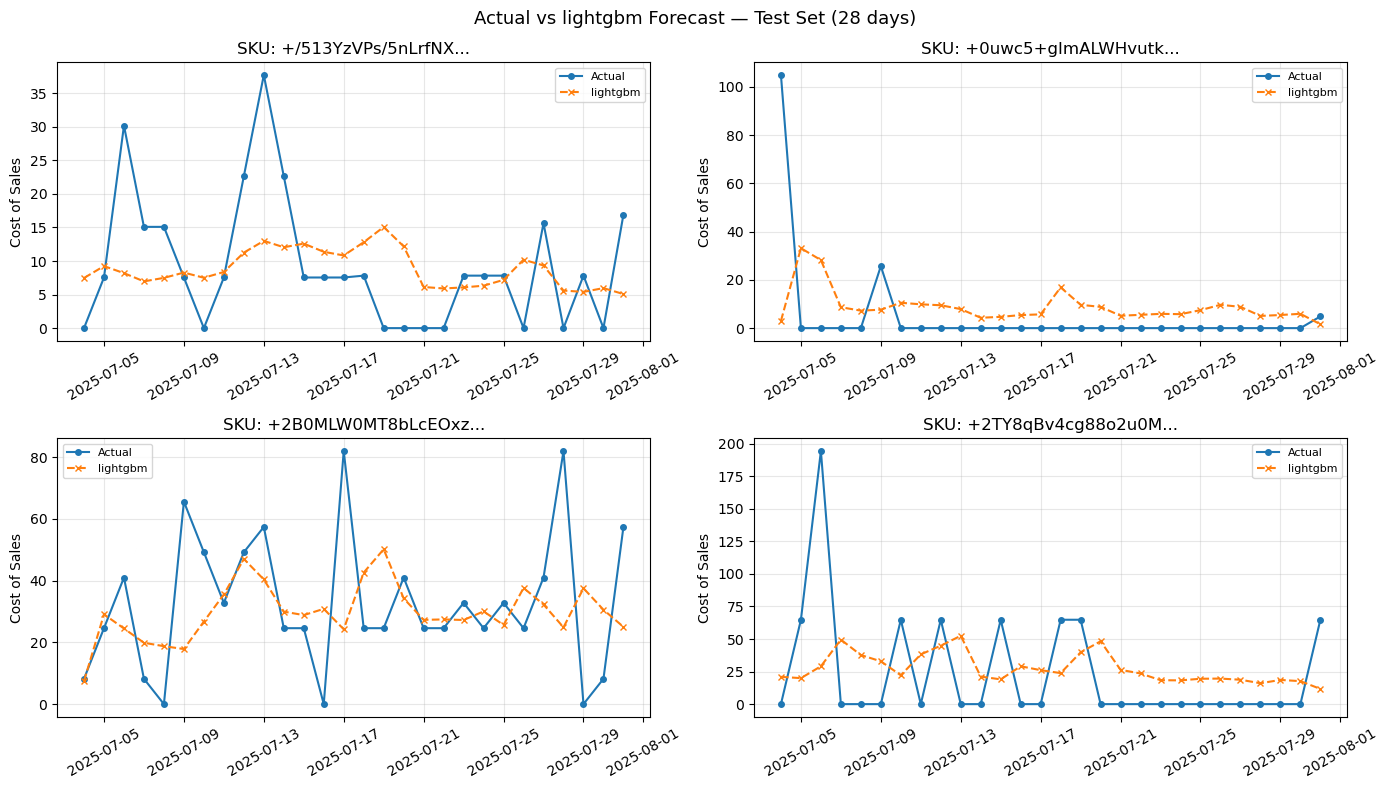

In [15]:
example_skus = te_final['sku'].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, sku in zip(axes, example_skus):
    sub = te_final[te_final['sku'] == sku].sort_values('date')
    ax.plot(sub['date'], sub['y'],    label='Actual',             marker='o', ms=4)
    ax.plot(sub['date'], sub['pred'], label=best_global_name,      marker='x', ms=4, linestyle='--')
    ax.set_title(f'SKU: {sku[:18]}...')
    ax.set_ylabel('Cost of Sales')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Actual vs {best_global_name} Forecast — Test Set (28 days)', fontsize=13)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

=== sMAPE ===
All days      : 137.48
Non-zero days : 64.89
Non-zero days account for 46.3% of test rows

=== Absolute MAE (per SKU, averaged over test window) ===
count    9328.000
mean       21.994
std       104.043
min         1.456
25%         5.263
50%         9.507
75%        19.502
max      7204.201

=== Per-SKU non-zero sMAPE distribution ===
count    9255.00
mean       89.41
std        43.09
min         3.50
25%        54.69
50%        77.56
75%       118.77
max       200.00


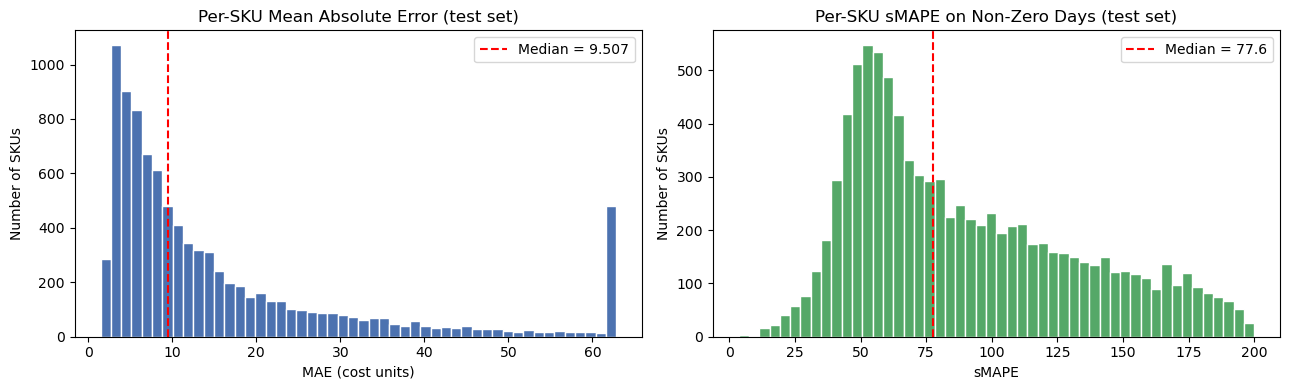

In [16]:
# ── Non-zero sMAPE and absolute MAE diagnostics ────────────────────────────
mask_nonzero = te_final['y'] > 0

print('=== sMAPE ===')
print(f'All days      : {smape(te_final["y"], te_final["pred"]):.2f}')
print(f'Non-zero days : {smape(te_final.loc[mask_nonzero, "y"], te_final.loc[mask_nonzero, "pred"]):.2f}')
print(f'Non-zero days account for {mask_nonzero.mean():.1%} of test rows')

print('\n=== Absolute MAE (per SKU, averaged over test window) ===')
te_final['abs_err'] = (te_final['y'] - te_final['pred']).abs()
per_sku_mae = te_final.groupby('sku')['abs_err'].mean()
print(per_sku_mae.describe().round(3).to_string())

print('\n=== Per-SKU non-zero sMAPE distribution ===')
def smape_nonzero(g):
    m = g['y'] > 0
    if m.sum() == 0:
        return np.nan
    return smape(g.loc[m, 'y'], g.loc[m, 'pred'])

per_sku_smape_nz = te_final.groupby('sku').apply(smape_nonzero).rename('smape_nz')
print(per_sku_smape_nz.dropna().describe().round(2).to_string())

# Plot distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(per_sku_mae.clip(upper=per_sku_mae.quantile(0.95)), bins=50,
             color='#4C72B0', edgecolor='white')
axes[0].axvline(per_sku_mae.median(), color='red', linestyle='--',
                label=f'Median = {per_sku_mae.median():.3f}')
axes[0].set_title('Per-SKU Mean Absolute Error (test set)')
axes[0].set_xlabel('MAE (cost units)')
axes[0].set_ylabel('Number of SKUs')
axes[0].legend()

axes[1].hist(per_sku_smape_nz.dropna().clip(upper=200), bins=50,
             color='#55A868', edgecolor='white')
axes[1].axvline(per_sku_smape_nz.median(), color='red', linestyle='--',
                label=f'Median = {per_sku_smape_nz.median():.1f}')
axes[1].set_title('Per-SKU sMAPE on Non-Zero Days (test set)')
axes[1].set_xlabel('sMAPE')
axes[1].set_ylabel('Number of SKUs')
axes[1].legend()

plt.tight_layout()
plt.savefig('diagnostics_nonzero.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 12-Month Recursive Forecast

Uses the best CV model (`best_global_name`) with a **recursive multi-step** strategy:  
for each future day, lag features are computed from the rolling buffer of actual + previously predicted values, then all SKUs are predicted simultaneously.  
Horizon: 365 days from the day after the last observation.

In [17]:
FORECAST_DAYS = 365
BUFFER_SIZE   = 28
LAGS          = [1, 2, 3, 7, 14, 21, 28]

forecast_start = GLOBAL_END + pd.Timedelta(days=1)
forecast_dates = pd.date_range(forecast_start, periods=FORECAST_DAYS, freq='D')
buf_dates      = pd.date_range(GLOBAL_END - pd.Timedelta(days=BUFFER_SIZE - 1), GLOBAL_END, freq='D')

eligible_list = list(eligible)
n_skus        = len(eligible_list)
sku_to_idx    = {s: i for i, s in enumerate(eligible_list)}
sku_ids_arr   = np.array([sku_enc.get(s, 0) for s in eligible_list])

# ── Sales history buffer ──────────────────────────────────────────────────────
print(f'Initialising sales buffer for {n_skus:,} SKUs...')
buffer_matrix = np.zeros((n_skus, BUFFER_SIZE))
for sku, grp in df[df[SKU_COL].isin(eligible)].groupby(SKU_COL):
    s = grp.set_index(DATE_COL)[TARGET].sort_index()
    buffer_matrix[sku_to_idx[sku]] = s.reindex(buf_dates, fill_value=0.0).values

# ── Promo static feature matrix for forecast horizon ─────────────────────────
# Shape: (n_skus, FORECAST_DAYS, n_static_promo)
# promo_feat covers dates up to 2025-09-25 — known schedule used directly;
# dates beyond that are filled with 0 (no promotion assumed).
print('Building promo feature matrix for forecast horizon...')
promo_indexed = (
    promo_feat.rename(columns={SKU_COL: 'sku', DATE_COL: 'date'})
    [promo_feat[DATE_COL].isin(forecast_dates)]
    .set_index(['sku', 'date'])[PROMO_STATIC_COLS]
)
fc_idx = pd.MultiIndex.from_product([eligible_list, forecast_dates], names=['sku', 'date'])
promo_fc_arr = (
    promo_indexed.reindex(fc_idx, fill_value=0.0)
    .values
    .reshape(n_skus, FORECAST_DAYS, len(PROMO_STATIC_COLS))
)
known_promo_days = int((promo_fc_arr[:, :, 0] > 0).sum())
print(f'  Known promo SKU-days in forecast window: {known_promo_days:,}')

# ── Promo dynamic state initialisation ───────────────────────────────────────
# days_since_promo: days since last promotion per SKU as of GLOBAL_END
last_promo = (
    promo_feat[promo_feat[DATE_COL] <= GLOBAL_END]
    .groupby(SKU_COL)[DATE_COL].max()
)
days_since_promo_arr = np.full(n_skus, 999.0)
for i, sku in enumerate(eligible_list):
    if sku in last_promo.index:
        days_since_promo_arr[i] = float((GLOBAL_END - last_promo[sku]).days)

# promo_buffer: last 7 days of is_promo per SKU (for rolling_promo_7)
promo_buf_dates = pd.date_range(GLOBAL_END - pd.Timedelta(days=6), GLOBAL_END, freq='D')
promo_hist_idx  = pd.MultiIndex.from_product([eligible_list, promo_buf_dates], names=['sku', 'date'])
promo_buffer = (
    promo_feat.rename(columns={SKU_COL: 'sku', DATE_COL: 'date'})
    [promo_feat[DATE_COL].isin(promo_buf_dates)]
    .set_index(['sku', 'date'])['is_promo']
    .reindex(promo_hist_idx, fill_value=0.0)
    .values
    .reshape(n_skus, 7)
)

# ── Recursive forecast loop ───────────────────────────────────────────────────
print(f'Forecasting {FORECAST_DAYS} days ({forecast_dates[0].date()} → {forecast_dates[-1].date()})...')
forecast_matrix = np.zeros((n_skus, FORECAST_DAYS))

for i, date in enumerate(forecast_dates):
    lag_feats = np.column_stack([buffer_matrix[:, BUFFER_SIZE - k] for k in LAGS])
    roll7     = buffer_matrix[:, -7:].mean(axis=1)
    roll14    = buffer_matrix[:, -14:].mean(axis=1)
    roll28    = buffer_matrix.mean(axis=1)

    static_promo    = promo_fc_arr[:, i, :]       # (n_skus, 6)
    rolling_promo_7 = promo_buffer.sum(axis=1)    # (n_skus,)

    feat_arr = np.column_stack([
        sku_ids_arr, lag_feats, roll7, roll14, roll28,
        np.full(n_skus, date.dayofweek),
        np.full(n_skus, date.day),
        np.full(n_skus, date.month),
        static_promo,           # is_promo, discount_depth, type flags
        days_since_promo_arr,   # days_since_promo
        rolling_promo_7,        # rolling_promo_7
    ])

    preds = np.maximum(final_model.predict(feat_arr), 0.0)
    forecast_matrix[:, i] = preds

    # Update sales buffer
    buffer_matrix        = np.roll(buffer_matrix, -1, axis=1)
    buffer_matrix[:, -1] = preds

    # Update promo dynamic state
    today_is_promo       = promo_fc_arr[:, i, 0]
    days_since_promo_arr = np.where(today_is_promo == 1.0, 0.0,
                                    np.minimum(days_since_promo_arr + 1, 999.0))
    promo_buffer         = np.roll(promo_buffer, -1, axis=1)
    promo_buffer[:, -1]  = today_is_promo

    if (i + 1) % 60 == 0:
        print(f'  Day {i+1}/{FORECAST_DAYS}')

print('Done.')

forecast_long = (
    pd.DataFrame(forecast_matrix, index=eligible_list, columns=forecast_dates)
    .T.reset_index()
    .rename(columns={'index': DATE_COL})
    .melt(id_vars=DATE_COL, var_name=SKU_COL, value_name='forecast')
)
forecast_long.to_csv('forecast_12months_v2.csv', index=False)
print(f'Saved forecast_12months_v2.csv  ({len(forecast_long):,} rows)')

Initialising sales buffer for 20,412 SKUs...
Building promo feature matrix for forecast horizon...
  Known promo SKU-days in forecast window: 20,212
Forecasting 365 days (2025-08-01 → 2026-07-31)...
  Day 60/365
  Day 120/365
  Day 180/365
  Day 240/365
  Day 300/365
  Day 360/365
Done.
Saved forecast_12months_v2.csv  (7,450,380 rows)


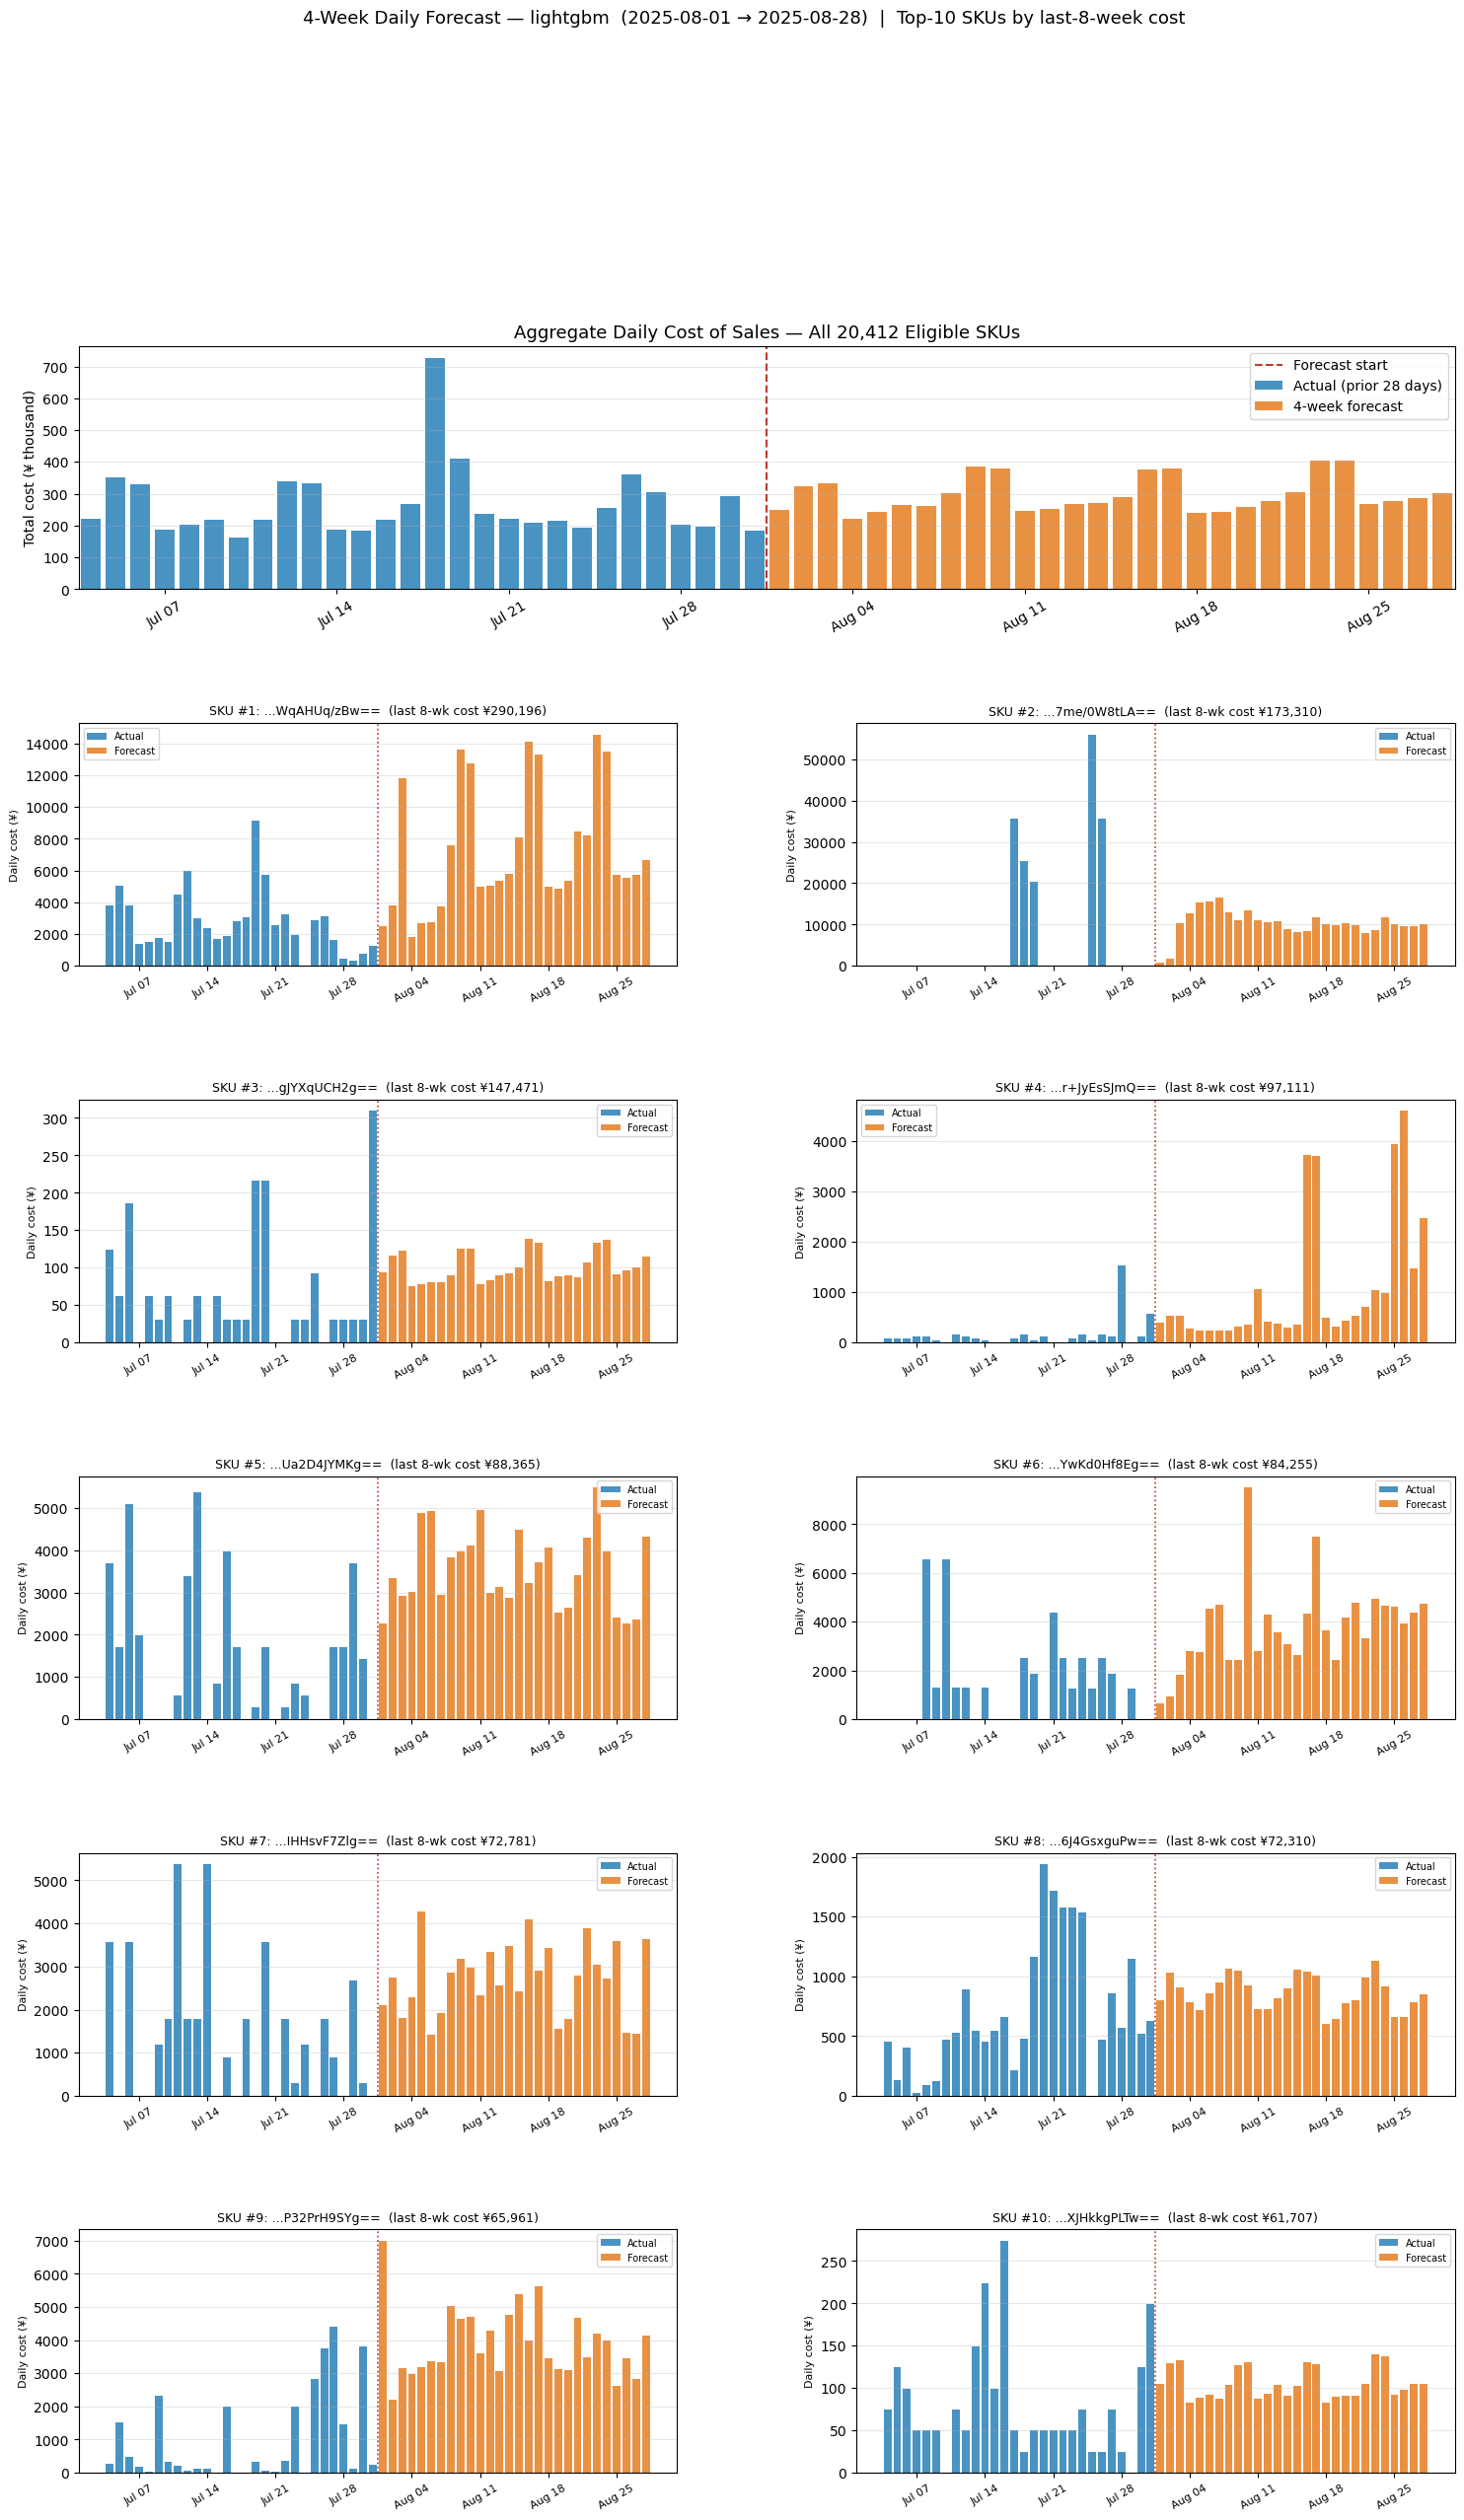

Aggregate 4-week forecast: ¥8,304,328
Prior 4-week actual:       ¥7,420,762
Top-10 SKUs (last 8 wks): ['psk8eshl1saPWqAHUq/zBw==', 'MUyxNOfLb8Mq7me/0W8tLA==', '2FPaCo4VS52zgJYXqUCH2g==', '2GwjVcZYQesDr+JyEsSJmQ==', '49wwpL4urOcDUa2D4JYMKg==', 'z2zzjMJHp5sEYwKd0Hf8Eg==', '/9wABmLEn1n6IHHsvF7Zlg==', 'Oj5VuinBeZdI6J4GsxguPw==', 'HiEXPR+suTLNP32PrH9SYg==', 'haiH8SEoJYH2XJHkkgPLTw==']


In [25]:
# ── 4-Week daily forecast: aggregate + top-10 SKUs by last-8-week sales ──────
PLOT_DAYS = 28    # 4 weeks exactly
FC_END_4W = forecast_dates[PLOT_DAYS - 1]

# Aggregate: prior 4 weeks actual + 4-week forecast
hist_daily = (
    df[df[DATE_COL] >= GLOBAL_END - pd.Timedelta(days=PLOT_DAYS - 1)]
    .groupby(DATE_COL)[TARGET].sum()
)
fc_daily = (
    forecast_long[forecast_long[DATE_COL] <= FC_END_4W]
    .groupby(DATE_COL)['forecast'].sum()
)

# Top-10 SKUs by cost of sales in the last 8 weeks (among eligible)
_8w_start  = GLOBAL_END - pd.Timedelta(weeks=8)
top10_skus = (
    df[df[SKU_COL].isin(eligible) & (df[DATE_COL] >= _8w_start)]
    .groupby(SKU_COL)[TARGET].sum()
    .nlargest(10)
    .index.tolist()
)

fig = plt.figure(figsize=(18, 28))
gs  = fig.add_gridspec(6, 2, hspace=0.55, wspace=0.3)

# ── Row 0: aggregate bar chart (spans both columns) ─────────────────────────
ax_agg = fig.add_subplot(gs[0, :])

ax_agg.bar(hist_daily.index, hist_daily.values / 1e3,
           color='#2980b9', alpha=0.85, width=0.8, label=f'Actual (prior {PLOT_DAYS} days)')
ax_agg.bar(fc_daily.index,   fc_daily.values / 1e3,
           color='#e67e22', alpha=0.85, width=0.8, label='4-week forecast')
ax_agg.axvline(forecast_start - pd.Timedelta(hours=12),
               color='#c0392b', ls='--', lw=1.5, label='Forecast start')
ax_agg.set_title(f'Aggregate Daily Cost of Sales — All {len(eligible_list):,} Eligible SKUs',
                 fontsize=13)
ax_agg.set_ylabel('Total cost (¥ thousand)')
ax_agg.legend(fontsize=10)
ax_agg.grid(alpha=0.3, axis='y')
ax_agg.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
ax_agg.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
ax_agg.tick_params(axis='x', rotation=30)
ax_agg.set_xlim(
    hist_daily.index.min() - pd.Timedelta(days=0.5),
    FC_END_4W              + pd.Timedelta(days=0.5)
)

# ── Rows 1–5: top-10 SKUs by last 8 weeks ────────────────────────────────────
hist_ctx_start = GLOBAL_END - pd.Timedelta(days=PLOT_DAYS - 1)
fc_4w = forecast_long[forecast_long[DATE_COL] <= FC_END_4W]

for idx, sku in enumerate(top10_skus):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row + 1, col])

    h = (df[(df[SKU_COL] == sku) & (df[DATE_COL] >= hist_ctx_start)]
         .set_index(DATE_COL)[TARGET].sort_index())
    f = (fc_4w[fc_4w[SKU_COL] == sku]
         .set_index(DATE_COL)['forecast'].sort_index())

    full_hist = h.reindex(pd.date_range(hist_ctx_start, GLOBAL_END, freq='D'), fill_value=0)
    full_fc   = f.reindex(pd.date_range(forecast_start, FC_END_4W,  freq='D'), fill_value=0)

    ax.bar(full_hist.index, full_hist.values,
           color='#2980b9', alpha=0.85, width=0.8, label='Actual')
    ax.bar(full_fc.index,   full_fc.values,
           color='#e67e22', alpha=0.85, width=0.8, label='Forecast')
    ax.axvline(forecast_start - pd.Timedelta(hours=12),
               color='#c0392b', ls=':', lw=1.2)

    last8w_cost = df[(df[SKU_COL] == sku) & (df[DATE_COL] >= _8w_start)][TARGET].sum()
    short_id    = str(sku)[-12:]
    ax.set_title(f'SKU #{idx+1}: ...{short_id}  (last 8-wk cost ¥{last8w_cost:,.0f})', fontsize=9)
    ax.set_ylabel('Daily cost (¥)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, axis='y')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
    ax.tick_params(axis='x', rotation=30, labelsize=8)

fig.suptitle(
    f'4-Week Daily Forecast — {best_global_name}  '
    f'({forecast_start.date()} → {FC_END_4W.date()})  |  Top-10 SKUs by last-8-week cost',
    fontsize=13, y=1.002
)
plt.savefig('forecast_4weeks.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Aggregate 4-week forecast: ¥{fc_daily.sum():,.0f}')
print(f'Prior 4-week actual:       ¥{hist_daily.sum():,.0f}')
print(f'Top-10 SKUs (last 8 wks): {top10_skus}')
